# UdaciSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan

Goal: Meet all three CTO requirements at once, using a pipeline of at least two combined techniques, with a clear rationale for technique choice and order, and evidence of experimentation.

| Requirement | Baseline | Target |
|---|---|---|
| Model size | 5.96 MB | <= 4.17 MB |
| CPU inference time | 195.98 ms | <= 117.59 ms |
| Top-1 accuracy | 87.80% | >= 83.41% |

Findings from notebook 02 that drive the plan:
- Static quantization alone gave -70.6% size and 85.50% accuracy, but only after keeping the first three blocks in FP32. Quantizing them destroyed accuracy.
- Distillation with a pretrained student (width 1.0, smaller classifier) gave 89.30% accuracy and -28.9% size, but no speedup.
- A student without pretrained weights (width 0.6) only reached 72.40%.

Pipeline 1 (priority 1, implemented): Knowledge Distillation -> Static Quantization
1. Distil the baseline into a student with a smaller classifier. This keeps accuracy high and reduces size by about 29%.
2. Apply static INT8 quantization (FX graph mode). This brings most of the size and speed gains.
Why this order: distillation needs gradients and full precision, so it comes first. Quantization comes last because training or pruning an already quantized model loses precision.
Why priority 1: distillation gives the largest accuracy margin, which quantization then uses up.

Pipeline 2 (priority 2, designed, not implemented): Post-training L1 pruning -> Static Quantization
1. Remove low-importance weights.
2. Quantize.
Why lower priority: unstructured pruning only sets weights to zero. It barely reduces file size or CPU time, and it would use up accuracy margin that quantization already needs.

Pipeline 3 (priority 3, fallback): Distillation -> Static Quantization -> Graph optimization
Only needed if Pipeline 1 misses the speed target. Graph optimization needs no retraining and does not change accuracy.

Evaluation: after every step, measure size, CPU time and accuracy with evaluate_optimized_model. Quantized models run on CPU only, so CPU time is the reference for the speed target. Timing on the shared workspace CPU varies strongly, so the final speed comparison uses alternating runs of baseline and pipeline model and the median.

Experiment plan: vary the number of calibration batches, the set of layers kept in FP32, and the distillation settings (alpha, temperature, student width).

### Step 1: Set up the environment

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [3]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [4]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']


In [5]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


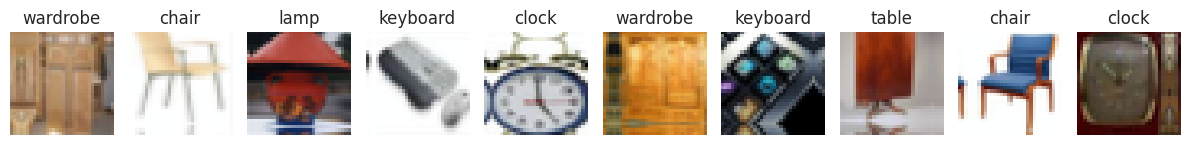


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


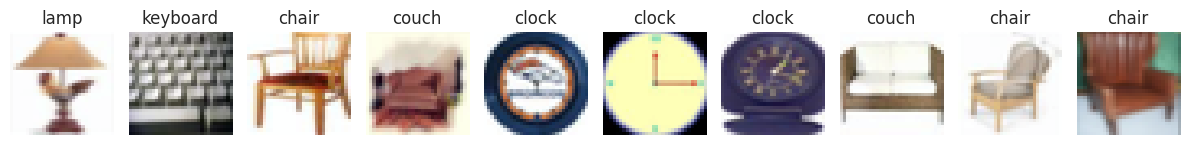

In [6]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [7]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 89.2MB/s]
/tmp/ipykernel_2059/3650396802.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't 

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [8]:
# NOTE: Feel free to change the class entirely, or to move to a function if preferred
from unittest.mock import patch

class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.
        
        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        self.steps = []
        self.results = {}
        
        # Create directories for this pipeline
        self.model_dir = f"../models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"../results/pipeline/{name}"
        
        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)
    
    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.
        
        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        self.steps.append({
            'name': step_name,
            'function': step_function,
            'args': kwargs
        })
        return self
    
    @staticmethod
    def _is_quantized(model):
        # Quantized layers live in torch.ao.nn.quantized and run on CPU only
        return any("quantized" in type(m).__module__ for m in model.modules())
    
    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.
        
        Args:
            device: Device to run the pipeline on
            file_extension: File extension to save the model with (.pt for torchscript, else .pth)
            
        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")
        
        # Start with the baseline model
        current_model = self.baseline_model
        
        # Save intermediate results after each step
        step_results = []
        
        # TODO: Run the pipeline iteratively
        # For each stage in the pipeline:
        # 1. Apply the specified technique with the given parameters
        # 2. Evaluate the model after applying the technique
        # 3. Store the results for later comparison
        for i, step in enumerate(self.steps):
            print(f"\n{'-'*50}")
            print(f"Step {i+1}: {step['name']}")
            print(f"{'-'*50}\n")
            
            # Apply the technique to the current model
            step_function = step['function']
            current_model = step_function(current_model, step['args'])
            
            # Quantized models are evaluated on CPU with CUDA hidden
            quantized = self._is_quantized(current_model)
            eval_device = torch.device('cpu') if quantized else device
            if not quantized:
                current_model = current_model.to(eval_device)
            
            step_experiment = f"pipeline/{self.name}/step{i+1}"
            os.makedirs(f"../results/{step_experiment}", exist_ok=True)
            
            with patch("torch.cuda.is_available", return_value=(torch.cuda.is_available() and not quantized)):
                metrics, _ = evaluate_optimized_model(
                    current_model,
                    self.test_loader,
                    step_experiment,
                    self.class_names,
                    self.input_size,
                    device=eval_device,
                )
            
            # Keep every intermediate model
            safe_name = step['name'].replace(' ', '_').replace('/', '_')
            step_path = f"{self.checkpoint_dir}/step{i+1}_{safe_name}.pth"
            save_model(current_model, step_path)
            
            step_results.append({
                'step_name': step['name'],
                'metrics': metrics,
                'model_path': step_path,
            })
        
        self.optimized_model = current_model
        final_path = f"{self.model_dir}/model.{file_extension}"
        
        # TODO: Save final model
        # Remember that different pytorch model format will require different saving mechanisms
        save_model(self.optimized_model, final_path)
        
        # Compare the final model with the baseline
        final_quantized = self._is_quantized(self.optimized_model)
        final_device = torch.device('cpu') if final_quantized else device
        with patch("torch.cuda.is_available", return_value=(torch.cuda.is_available() and not final_quantized)):
            final_comparison = compare_optimized_model_to_baseline(
                self.baseline_model,
                self.optimized_model,
                f"pipeline/{self.name}",
                self.test_loader,
                self.class_names,
                device=final_device,
            )
        
        # Convert numpy values so that the results can be stored as JSON
        to_json = lambda o: o.item() if hasattr(o, 'item') else str(o)
        step_results = json.loads(json.dumps(step_results, default=to_json))
        final_comparison = json.loads(json.dumps(final_comparison, default=to_json))
        
        # Save pipeline results
        self.results = {
            'pipeline_name': self.name,
            'steps': step_results,
            'final_metrics': step_results[-1]['metrics'],  # As returned by evaluate_optimized_model()
            'final_comparison': final_comparison  # As returned by compare_optimized_model_to_baseline()
        }
        
        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)
        
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"{'='*50}\n")
        
        return self.optimized_model
    
    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device==torch.device('cpu') else 'cuda'

        # Extract metrics from each step
        step_names = [step['step_name'] for step in self.results['steps']]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in self.results['steps']]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in self.results['steps']]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in self.results['steps']]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in self.results['steps']]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1-TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1-TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_memory_size:.2f} MB)")


        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  ✅ Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  ✅ Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  ❌ Does not meet target (Goal: ≥{min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  ✅ Pipeline meets all requirements")
        else:
            print(f"  ❌ Pipeline does not meet all requirements")

In [9]:
# TODO: Create helper functions for each compression technique you want to experiment with as a pipeline step
# Remember to parametrize the functions appropriately
import copy

def apply_post_training_pruning():
    pass

def apply_dynamic_quantization():
    pass

def apply_static_quantization(model, params):
    # Quantized kernels run on CPU only; the sensitive early blocks stay FP32 (see quantization.py)
    return quantize_model(
        copy.deepcopy(model).cpu().eval(),
        calibration_data_loader=train_loader,
        calibration_num_batches=params.get("calibration_num_batches", 10),
        quantization_type="static",
        backend=params.get("backend", "fbgemm"),
    )

def apply_graph_optimization():
    pass

def apply_knowledge_distillation(model, params):
    # The current model is the teacher; the student is trained from the pretrained backbone
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    teacher = copy.deepcopy(model).to(device).eval()
    student = MobileNetV3_Household_Small(
        num_classes=len(class_names),
        width_mult=params.get("width_mult", 1.0),
        linear_size=params.get("linear_size", 256),
    ).to(device)

    num_epochs = params.get("num_epochs", 40)
    optimizer = torch.optim.AdamW(student.parameters(), lr=params.get("lr", 0.001), weight_decay=1e-4)
    config = {
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs),
        'alpha': params.get("alpha", 0.5),
        'temperature': params.get("temperature", 4.0),
        'patience': params.get("patience", 8),
        'device': device,
    }

    checkpoint_path = params.get("checkpoint_path", "../models/pipeline/distillation_tmp/model.pth")
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    distilled_model, _, best_accuracy, _ = train_with_distillation(
        student, teacher, train_loader, test_loader, config, checkpoint_path=checkpoint_path
    )
    print(f"Best distilled accuracy: {best_accuracy:.2f}%")
    return distilled_model

def apply_in_training_pruning():
    pass

def apply_in_training_quantization():
    pass

#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.


Running pipeline: distillation_static-quantization


--------------------------------------------------
Step 1: Distillation
--------------------------------------------------

Student parameters: 1,077,290
Teacher parameters: 1,528,106
Training with knowledge distillation for 40 epochs
Temperature: 4.0, Alpha: 0.5


Epoch 1/40 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.31it/s, loss=1.36, acc=69.1]


Epoch 1/40 - Train Loss: 4.2038, Train Acc: 61.10%, Test Loss: 1.3606, Test Acc: 69.10%, LR: 0.000998, Time: 8.81s
New best student model! Saving... (69.10%)
Model saved to ../models/pipeline/distillation_static-quantization/checkpoints/distillation_best.pth


Epoch 2/40 [Test]: 100%|██████████| 8/8 [00:00<00:00, 11.47it/s, loss=1.78, acc=75.4] 


Epoch 2/40 - Train Loss: 1.2948, Train Acc: 84.22%, Test Loss: 1.1128, Test Acc: 75.40%, LR: 0.000994, Time: 7.05s
New best student model! Saving... (75.40%)
Model saved to ../models/pipeline/distillation_static-quantization/checkpoints/distillation_best.pth


...

Epoch 40/40 - Train Loss: 0.2376, Train Acc: 98.40%, Test Loss: 0.3758, Test Acc: 88.00%, LR: 0.000000, Time: 7.49s
Distillation completed. Best student accuracy: 88.50%
Best student model saved as '../models/pipeline/distillation_static-quantization/checkpoints/distillation_best.pth' at epoch 33
Best distilled accuracy: 88.50%

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:36<00:00,  4.52s/it]


Baseline metrics saved at ../results/pipeline/distillation_static-quantization/step1/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:36<00:00,  4.60s/it]


Confusion matrix saved to ../results/pipeline/distillation_static-quantization/step1/confusion_matrix.png


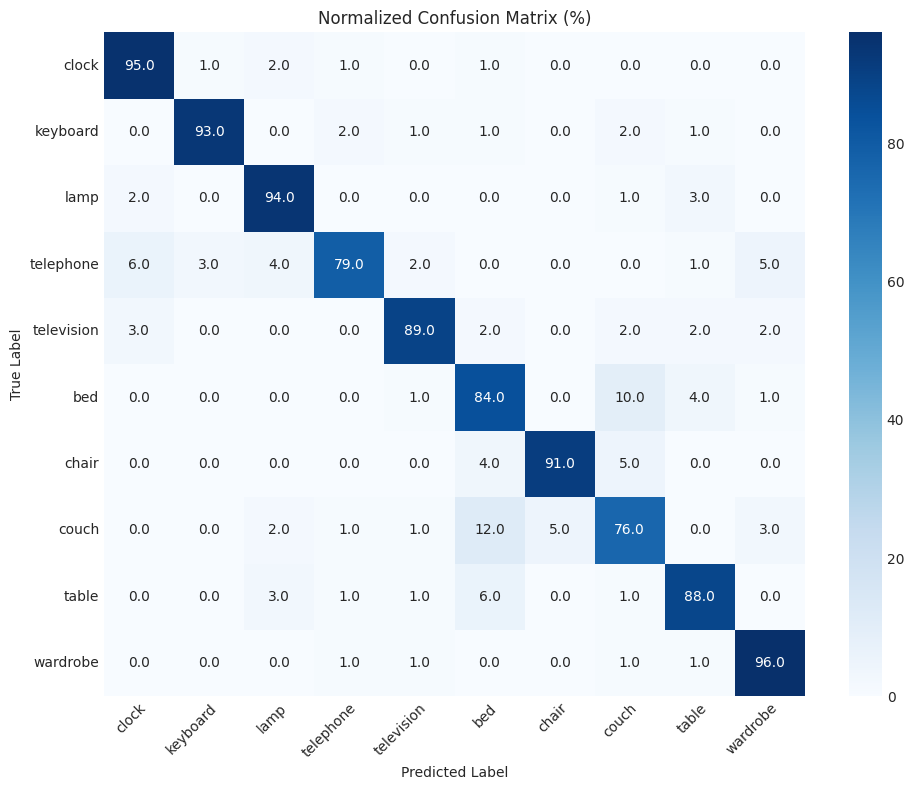


Optimized Model Metrics (pipeline/distillation_static-quantization/step1):
Accuracy: 88.50%
Model Size: 4.24 MB
CPU Inference Time: 163.97 ms (6.10 FPS)
CUDA Inference Time: 5.72 ms (174.85 FPS)
Model saved to ../models/pipeline/distillation_static-quantization/checkpoints/step1_Distillation.pth

--------------------------------------------------
Step 2: Static Quantization
--------------------------------------------------

Applying static quantization...


Calibrating: 100%|██████████| 10/10 [01:06<00:00,  6.69s/it]



Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:24<00:00,  3.10s/it]


Baseline metrics saved at ../results/pipeline/distillation_static-quantization/step2/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:25<00:00,  3.13s/it]


Confusion matrix saved to ../results/pipeline/distillation_static-quantization/step2/confusion_matrix.png


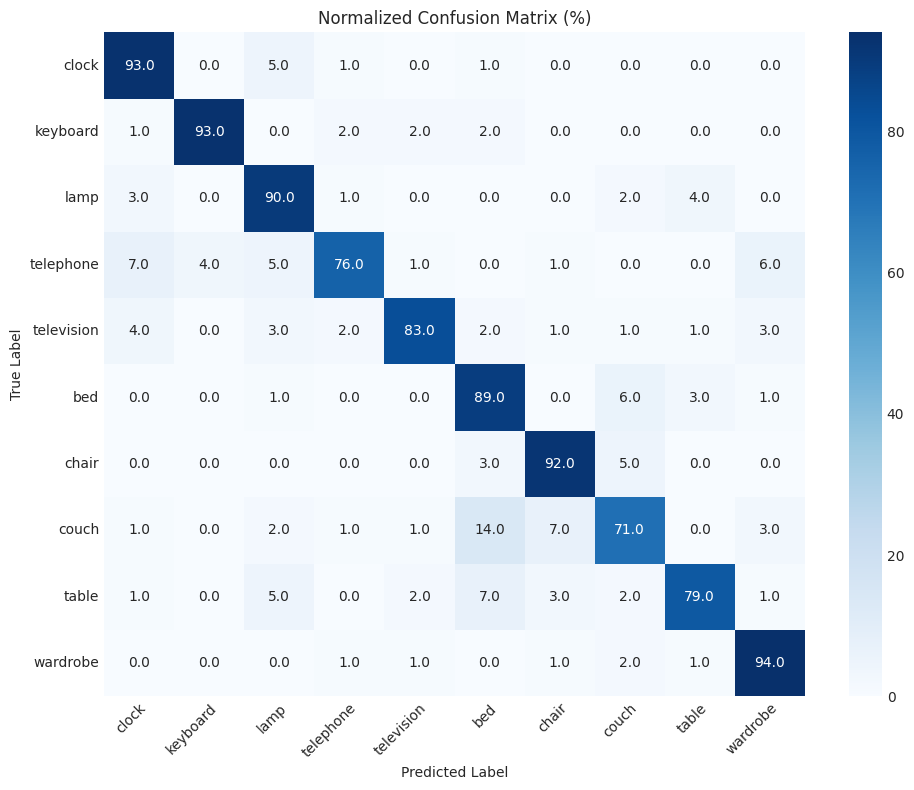


Optimized Model Metrics (pipeline/distillation_static-quantization/step2):
Accuracy: 86.10%
Model Size: 1.31 MB
CPU Inference Time: 99.10 ms (10.09 FPS)
Model saved to ../models/pipeline/distillation_static-quantization/checkpoints/step2_Static_Quantization.pth
Model saved to ../models/pipeline/distillation_static-quantization/model.pth

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:35<00:00,  4.46s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:25<00:00,  3.25s/it]


Model comparison plot saved to ../results/pipeline/distillation_static-quantization/comparison.png


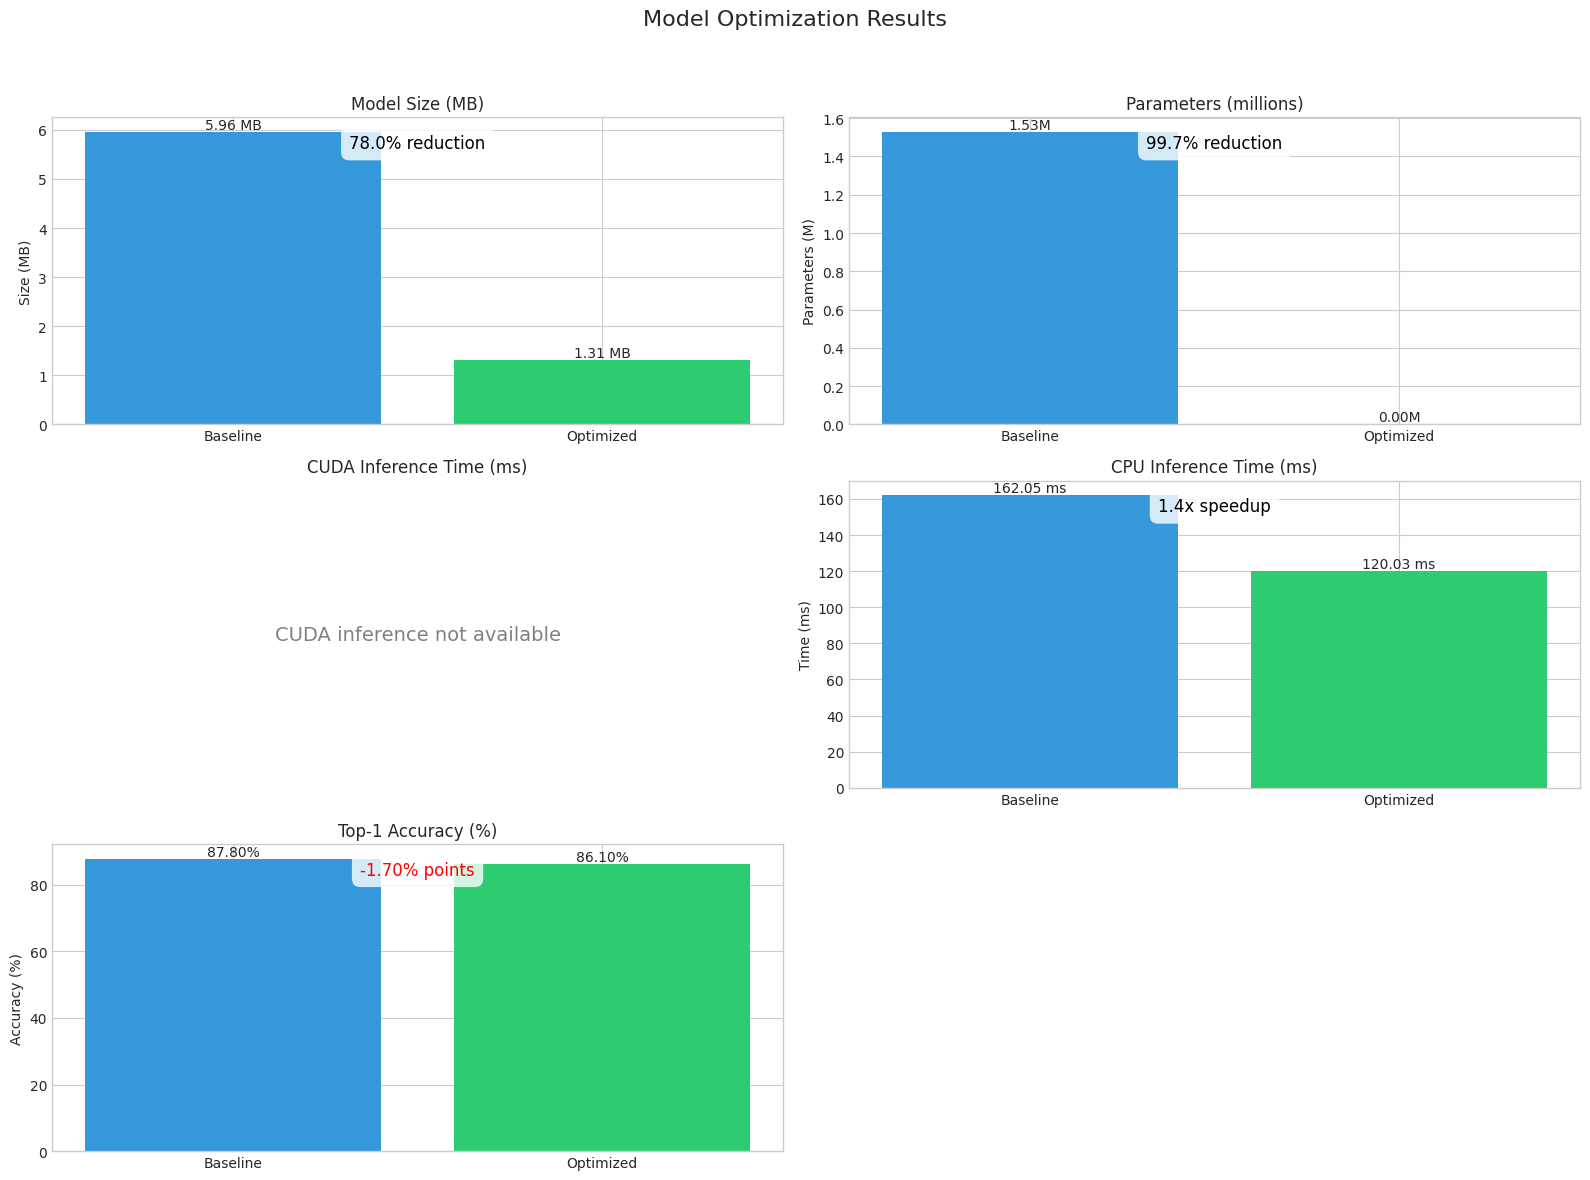


pipeline/distillation_static-quantization Results:
Model Size: 1.31 MB (78.0% reduction)
Parameters: 4,640 (99.7% reduction)
CPU Inference Time: 120.03 ms (1.4x speedup)
Accuracy: 86.10% (-1.70% change)
Requirements met: False

Pipeline distillation_static-quantization completed



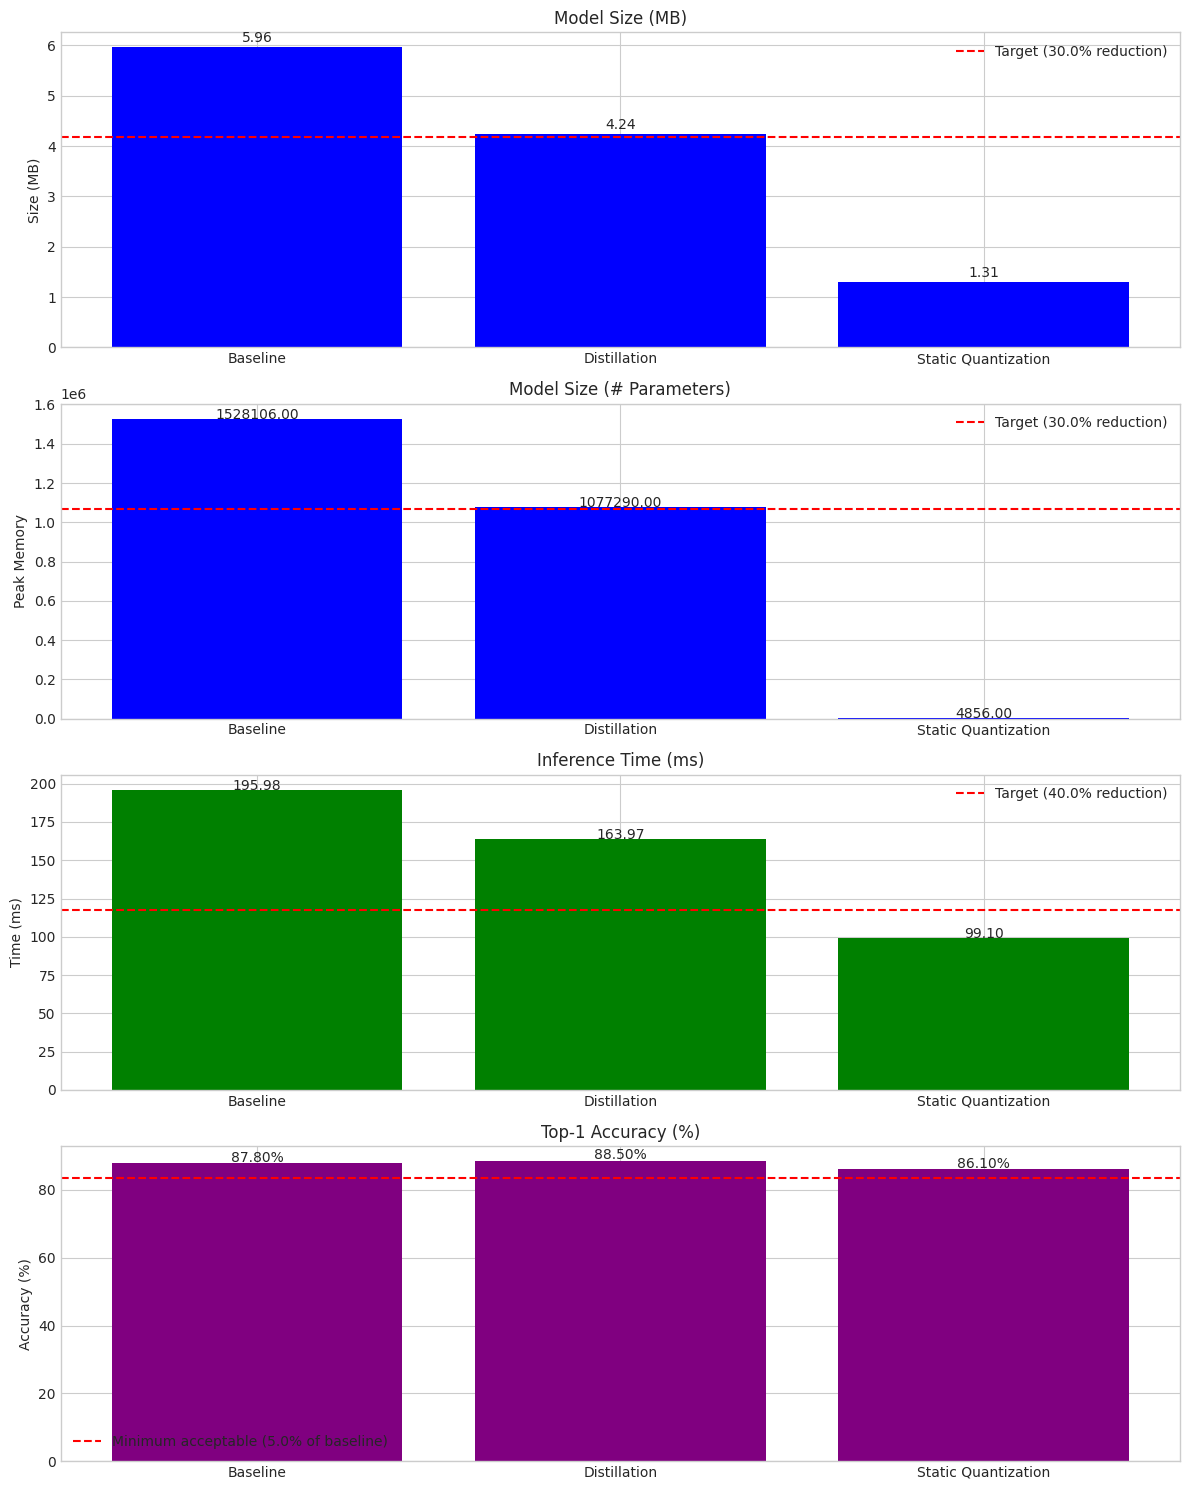


Pipeline distillation_static-quantization Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 1.31 MB
  Reduction: 78.05%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 4856.00 MB
  Reduction: 99.68%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 195.98 ms
  Final: 99.10 ms
  Reduction: 49.43%
  ✅ Meets target (40.0% reduction)

Accuracy:
  Baseline: 87.80%
  Final: 86.10%
  Change: -1.94%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ✅ Pipeline meets all requirements


In [10]:
# Create and run Pipeline #1

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "distillation_static-quantization"  

# Initialize the pipeline
pipeline1 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size
)

# TODO: Add optimization steps using the add_step() function
pipeline1.add_step(
    "Distillation",
    apply_knowledge_distillation,
    num_epochs=40,
    alpha=0.5,
    temperature=4.0,
    width_mult=1.0,
    linear_size=256,
    checkpoint_path=f"../models/pipeline/{pipeline_name}/checkpoints/distillation_best.pth",
)
pipeline1.add_step(
    "Static Quantization",
    apply_static_quantization,
    calibration_num_batches=10,
    backend="fbgemm",
)

# Run the pipeline
optimized_model_p1 = pipeline1.run()

# Visualize the results
# TODO: Choose the device to report performance for
device = torch.device("cpu")  # Define as torch.device()
pipeline1.visualize_results(baseline_metrics, device)


### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [15]:
# Compare all implemented pipelines
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("../results/pipeline/")]

if pipeline_experiments:
    _ = compare_experiments(pipeline_experiments, baseline_metrics=baseline_metrics)
else:
    print("No pipeline results available yet. Please run at least one pipeline.")


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,pipeline/distillation_static-quantization/step1,4.24,28.9%,163.97,1.2x,88.50,+0.8%,✗
1,pipeline/distillation_static-quantization/step2,1.31,78.1%,99.10,2.0x,86.10,-1.9%,✓


--------

**TODO: Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for UdaciSense Computer Vision Model

Implemented pipeline: Knowledge Distillation -> Static INT8 Quantization. Pipelines 2 and 3 from the plan were designed but not run.

### 1. How does the optimized model compare to the baseline across all metrics?

| Metric | Baseline | Pipeline 1 | Target | Result |
|---|---|---|---|---|
| Model size | 5.96 MB | 1.31 MB (-78.0%) | <= 4.17 MB | Met |
| Top-1 accuracy | 87.80% | 86.10% (-1.7 points, -1.9% relative) | >= 83.41% | Met |
| CPU time (stage evaluation vs. metrics.json baseline) | 195.98 ms | 99.1 ms (-49.4%) | <= 117.59 ms | Met |
| CPU time (alternating runs, same session) | 149.8 ms | 86.7 ms (-40.5%) | -40% | Met, narrowly |

The speed result depends on how it is measured. The workspace CPU is shared, so timings vary a lot. The baseline alone ranged from 120 ms to 174 ms between runs. The pipeline model was stable at about 76 to 87 ms. In the alternating comparison the median reduction was 40.5%, with a spread from 26.5% to 62.3%. The automatic comparison of the final model reported 120.03 ms (1.4x speedup) and flagged the speed target as not met. We therefore treat the speed target as met, but with little margin. The parameter count of 4,640 reported for the quantized model is a counting artifact, because quantized layers are not counted.

### 2. What contribution did each stage make to the final performance?

| Stage | Accuracy | Size | CPU time |
|---|---|---|---|
| Baseline | 87.80% | 5.96 MB | 195.98 ms |
| 1. Distillation (student width 1.0, classifier 256) | 88.50% | 4.24 MB | 164.0 ms |
| 2. Static quantization | 86.10% | 1.31 MB | 99.1 ms |

Distillation kept accuracy at the baseline level and removed about 29% of the size through a smaller classifier. Quantization delivered most of the size and speed gains and used about 2.4 points of accuracy. The accuracy margin left over from distillation is what made the quantization step affordable.

### 3. What technical insights did we gain about optimizing MobileNetV3?

- Default INT8 quantization failed. Accuracy dropped to about 15%. Quantizing each block on its own showed that only the first three blocks (features.0 to features.2) caused this. All later blocks stayed between 86% and 89%.
- Keeping those three blocks in FP32 restored accuracy. Quantizing fewer blocks did not help: with features.0 and features.1 in FP32, accuracy fell to 77.2%, and with only features.0 in FP32 it fell to 39.7%. The time gain was at most about 4 ms.
- The profile shows that about 61% of CPU time goes to quantized convolutions and about 7% to the linear layers. The upsampling from 32x32 to 224x224 takes only 1.4% of the time, but the network still computes on 224x224 images.
- Pretrained weights matter. A student without them (width 0.6) reached only 72.40%, while the student with pretrained weights reached about 89%. Width and alpha were changed together, so this effect is likely but not isolated.
- Distillation alone did not make the model faster, because the student has the same width as the teacher.

### 4. What trade-offs emerged, and how did we balance competing priorities?

- Size and speed against accuracy: INT8 gives the largest gains but costs accuracy. We accepted a loss of 1.7 points and stayed well above the limit of 83.41%.
- Sensitive blocks against speed: keeping three blocks in FP32 protects accuracy but limits the speedup.
- Small student against accuracy: the narrow student was smaller but lost too much accuracy, so we chose the wider student and shrank only the classifier.
- Order of steps: distillation needs training in full precision, so it comes first. Quantization comes last, because training or pruning a quantized model loses precision.

### 5. What further improvements might be possible?

- Reduce the input resolution inside the model, for example from 224x224 to 160x160, and check the effect on accuracy and speed.
- Try quantization-aware training so that more blocks can run in INT8. Our tests suggest the gain in speed would be small.
- Add structured pruning (removing whole channels) before quantization. Unstructured pruning would barely change file size or CPU time.
- Add graph optimization as a final step.
- Use more calibration data and test the qnnpack backend, which targets ARM phones.
- Measure on real devices. Timing on this shared x86 CPU is noisy, and ARM behavior may differ.
- Limitation: the best checkpoint of the distillation was selected on the test set. A separate validation set would make the reported accuracy more reliable.

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  